# 02: from m/z peaks to lipid names

### CAJAL NEUROMICS summer school, Bordeaux 2026 · a spatial metabolomics primer

*Luca Fusar Bassini · hands-on notebook 2 of 9 · ~75 minutes*

---

In notebook 01 you saw the physics: a laser fires at a tiny spot of brain, the matrix
flings the molecules into the gas phase as charged ions, and the mass spectrometer
reports, for that spot, a list of mass-to-charge values with their intensities. Stack
those lists over the whole section and every pixel carries a spectrum. So far the machine
has handed us **numbers**, masses like 518.2644, and nothing else. It does not know that
this number is a lipid, let alone *which* lipid.

This notebook closes that gap. We turn a list of bare **m/z peaks** into a list of named
lipids, the operation called **annotation**. By the end you will be able to say, for a
real peak from our pregnant brain section, "this is LPE 18:1", and you will know exactly
how much to trust that sentence.

The plan, each idea built from the ground up:

> **a peak is not a lipid → adducts (one lipid, several masses) → de-ionization →
> the ppm formula → matching against an LC-MS reference → isobaric ties and how to
> break them → the database layer → lipid nomenclature → m/z columns become lipid columns**

We keep nothing as a black box. First we unroll the mechanics in a few transparent
lines so you see exactly what happens, then we call the matching helper in
`cajal_lipidomics` and confirm it does the same thing.

## the callouts, again

The same four markers run through every notebook in this course:

- 🔬 **TASK**: something you do (write or run code).
- 💡 **HINT**: a nudge when you are stuck.
- ❓ **QUESTION**: pause and think; no code required.
- ⚠️ **CHECKPOINT**: what you should see if it worked. If your screen disagrees, stop and fix it before moving on.

🔬 **TASK.** Run the next cell to load the libraries and the course helpers.


In [1]:
# the scientific-Python stack you already know
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

# the course package: tested helpers we lean on instead of reinventing
import cajal_lipidomics as cl
from cajal_lipidomics import annotation as cann   # the ppm matcher and the ppm plot
from cajal_lipidomics import plotting as cplot     # the spectrum and spatial-map figures
from cajal_lipidomics.style import set_style, FS
set_style()   # the clean, dense, Illustrator-editable figure style of the course

# one global seed so every number and figure below is reproducible
RNG_SEED = 0
rng = np.random.default_rng(RNG_SEED)

# where the data and the annotation references live
DATA = "/home/fusar/lipidomics_tutorial_cajalcourse/data"
REFS = f"{DATA}/refs/csv"

print("ready: pandas", pd.__version__, "| anndata", ad.__version__)

ready: pandas 2.3.3 | anndata 0.11.4


⚠️ **CHECKPOINT.** You should see `ready: pandas ... | anndata ...` and no red error.
A `ModuleNotFoundError` means the notebook is on the wrong kernel: pick the
`cajal-lipidomics` kernel (top-right kernel picker) and rerun.

## 1 · a peak is not a lipid

Let us start by looking at what the machine actually gave us. We load the course
substrate, the two coronal sections, control (a naive female, `217D`) and pregnant
(`Brain1_C2`), cut at the same plane around AP 6.5, and we look at the pregnant one.


In [2]:
# load the two-section substrate: 174768 pixels x 173 lipids, uMAIA-normalized
adata = ad.read_h5ad(f"{DATA}/sections_pair.h5ad")
print("whole substrate:", adata.shape, "(pixels x lipids)")

# keep only the pregnant section for this lesson (the real peak we annotate comes from it)
preg = adata[adata.obs["Condition"] == "pregnant"].copy()
print("pregnant section:", preg.shape, "pixels x lipids")
print("\nthe lipids are already NAMED in this file (var_names):")
print(list(preg.var_names[:6]))


whole substrate: (174768, 173) (pixels x lipids)


pregnant section: (90447, 173) pixels x lipids

the lipids are already NAMED in this file (var_names):
['HexCer 42:2;O2', 'HexCer 42:1;O2', 'HexCer 40:1;O2', 'PC 38:6', 'PA 34:1', 'SM 36:1;O2']


The substrate ships **already annotated**, its columns are lipid names, not raw
masses, because someone already did the work this notebook teaches. To learn that work
we need the raw masses back. They live in the project's annotation table,
`cleanedANNOTATIONS_20250215.csv`, which records, for every measured peak, its m/z and the
lipid name finally assigned to it. We load it and rebuild the mapping **name → m/z**, so we
can talk in masses again.


In [3]:
# the project's master annotation table: one row per measured MSI peak
clean = pd.read_csv(f"{REFS}/cleanedANNOTATIONS_20250215.csv").rename(columns={"Unnamed: 0": "mz"})
print("annotation table:", clean.shape, "peaks x columns")
print("columns we care about now:", ["mz", "Annotation", "Score", "Status"])

# build name -> m/z for the 173 lipids in our substrate
name2mz = clean.drop_duplicates("Annotation").set_index("Annotation")["mz"]
mz_of_lipid = name2mz.reindex(preg.var_names)
print("\nall", mz_of_lipid.notna().sum(), "substrate lipids carry an m/z:")
print(mz_of_lipid.head(6).round(4).to_string())


annotation table: (5798, 156) peaks x columns
columns we care about now: ['mz', 'Annotation', 'Score', 'Status']

all 173 substrate lipids carry an m/z:
HexCer 42:2;O2    848.6376
HexCer 42:1;O2    850.6538
HexCer 40:1;O2    822.6222
PC 38:6           844.5252
PA 34:1           713.4517
SM 36:1;O2        769.5621


⚠️ **CHECKPOINT.** All 173 substrate lipids map back to an m/z, and the masses run
from about 459 to 1143 Da, the mass window of brain lipids in positive-mode MALDI.

Now the picture that motivates the whole notebook. A spectrum is just two aligned arrays:
masses on one axis, intensities on the other. We average each lipid's intensity over all
pregnant pixels, place each stick at its m/z, and draw the **mean MALDI spectrum** of the
section. Every stick is one peak the machine reported.

🔬 **TASK.** Run the cell. The helper `cplot.spectrum` draws exactly the
`vlines(m/z, 0, intensity)` stick plot that mass spectrometrists call a centroid spectrum.


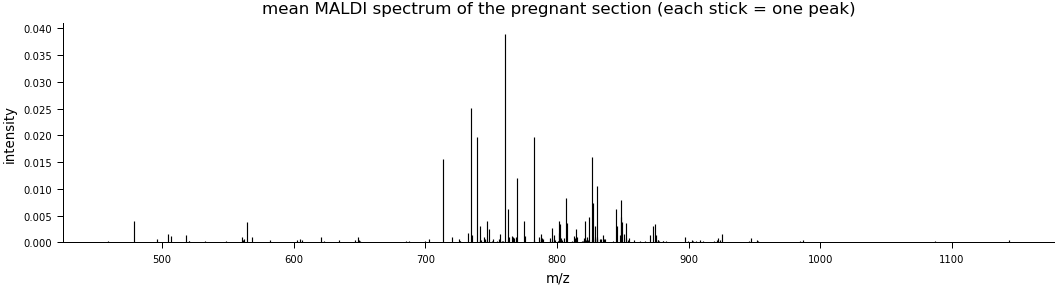

173 peaks span m/z 459.2 to 1143.0


In [4]:
# mean intensity per lipid across the pregnant pixels -> one stick height per peak
mean_int = np.asarray(preg.X).mean(axis=0)
mz_vals = mz_of_lipid.to_numpy()

# a spectrum is two aligned arrays; the helper draws the stick plot
ax = cplot.spectrum(mz_vals, mean_int,
                          title="mean MALDI spectrum of the pregnant section (each stick = one peak)")
plt.tight_layout(); plt.show()

print(f"{len(mz_vals)} peaks span m/z {mz_vals.min():.1f} to {mz_vals.max():.1f}")


Stare at that plot. Every stick is a number the machine is sure about: it measured
that mass to four decimal places. But not one stick is labelled with a molecule. The
instrument resolves **mass**, never **identity**. That is the central fact of this
notebook: a peak is a mass, and a mass is not a lipid.

Worse, the masses crowd together. Zoom into a narrow window and you see several sticks
almost on top of each other. We zoom into 505 to 535 Da, the lyso-lipid neighbourhood,
where our target peak lives.


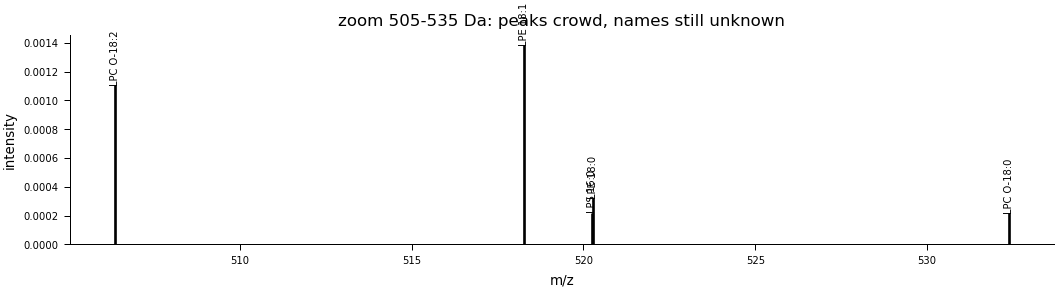

In [5]:
# zoom into a crowded window to show peaks crowding near the same mass
lo, hi = 505, 535
win = (mz_vals >= lo) & (mz_vals <= hi)
ax = cplot.spectrum(mz_vals[win], mean_int[win], lw=1.6,
                          title=f"zoom {lo}-{hi} Da: peaks crowd, names still unknown")
# label each stick with its (still secret) lipid name, just to see how close they sit
for m, name in zip(mz_vals[win], mz_of_lipid.index[win]):
    ax.annotate(name, (m, mean_int[win][mz_vals[win] == m][0]), rotation=90,
                ha="center", va="bottom", fontsize=FS["xs"])
plt.tight_layout(); plt.show()


❓ **QUESTION.** Two of those peaks sit within a few hundredths of a Dalton of each
other. If the machine had been a little less precise, could you have told them apart from
the mass alone? Hold that thought: it is the whole reason annotation needs a tolerance, and
the reason ties happen.


## 2 · adducts: one lipid wears several masses

Here is the first twist that makes annotation non-trivial. The mass spectrometer never sees
a neutral molecule. It can only detect **ions**, molecules carrying a charge. In
positive-mode MALDI a lipid grabs a small positive ion before it flies, and the mass the
machine reports is the lipid's neutral mass **plus** the mass of whatever it grabbed. The
thing it grabs is called an **adduct**.

In positive mode brain lipids show up mostly as four adducts:

| adduct | what attaches | added mass (Da) |
|---|---|---|
| `[M+H]+`   | a proton            | 1.007276 |
| `[M+Na]+`  | a sodium ion        | 22.989769 |
| `[M+K]+`   | a potassium ion     | 38.963707 |
| `[M+NH4]+` | an ammonium ion     | 18.033823 |

So **one lipid appears at several different m/z**, one per adduct it forms. The same
molecule, seen four times, four masses apart by exactly those four numbers. These masses
are not arbitrary: a proton is one hydrogen nucleus, sodium and potassium are the abundant
salts of tissue, ammonium comes from the buffer. The helper stores them for us.


In [6]:
# the positive-mode adduct masses the helper uses (Da added to the neutral mass)
print("ADDUCTS (positive mode):")
for name, mass in cann.ADDUCTS.items():
    print(f"  [M+{name[:-1]}]+   adds {mass:8.4f} Da")


ADDUCTS (positive mode):
  [M+H]+   adds   1.0073 Da
  [M+Na]+   adds  22.9898 Da
  [M+K]+   adds  38.9637 Da
  [M+NH4]+   adds  18.0338 Da


Let us make the idea concrete with one lipid. Take PC 34:1, a common membrane
phosphatidylcholine, neutral mass 759.5778 Da. Its four positive adducts land at four
different observed masses. We compute them by hand: **observed = neutral + adduct**.


In [7]:
# PC 34:1 neutral exact mass (Da); the four adducts spread it across four observed m/z
neutral_pc34_1 = 759.5778
print(f"PC 34:1 neutral mass = {neutral_pc34_1:.4f} Da")
print("appears in the spectrum at:")
for name, shift in cann.ADDUCTS.items():
    print(f"  [M+{name[:-1]}]+  ->  m/z {neutral_pc34_1 + shift:9.4f}")


PC 34:1 neutral mass = 759.5778 Da
appears in the spectrum at:
  [M+H]+  ->  m/z  760.5851
  [M+Na]+  ->  m/z  782.5676
  [M+K]+  ->  m/z  798.5415
  [M+NH4]+  ->  m/z  777.6116


⚠️ **CHECKPOINT.** The same single lipid is detected at four masses spanning roughly
760 to 798 Da: the sodium form sits 22 Da above the proton form, the potassium form 38 Da
above. If you did not know about adducts you would call these four peaks four different
molecules. This is why a raw peak list always has more peaks than lipids: adducts inflate
the count, and part of annotation is collapsing the duplicates back to one lipid.


## 3 · de-ionization: subtract the adduct to recover the neutral mass

Reference databases store the **neutral** exact mass of each lipid, the mass with no charge
attached, because that is the molecule's intrinsic property. The machine, by contrast,
reports the **ionized** mass. To compare the two we have to undo the ionization. The arrow
of section 2 ran neutral → observed by adding an adduct; we now run it backwards:

> **neutral = observed − adduct**

This is **de-ionization**. For each candidate adduct we strip its mass off the observed
peak and ask: does the leftover neutral mass match a known lipid? We do not know in advance
which adduct formed, so we try all four and keep whichever gives the closest match.

🔬 **TASK.** Take the observed peak we will spend the rest of the notebook on,
m/z 518.2644 from the pregnant section, and de-ionize it under each of the four adduct
hypotheses.


In [8]:
# the real MSI peak we will annotate, straight from the pregnant section
observed = 518.2644
print(f"observed peak: m/z {observed}")
print("under each adduct hypothesis, the implied neutral mass = observed - adduct:")
for name, shift in cann.ADDUCTS.items():
    print(f"  if it is [M+{name[:-1]}]+ :  neutral = {observed:.4f} - {shift:7.4f} = {observed - shift:9.4f} Da")


observed peak: m/z 518.2644
under each adduct hypothesis, the implied neutral mass = observed - adduct:
  if it is [M+H]+ :  neutral = 518.2644 -  1.0073 =  517.2571 Da
  if it is [M+Na]+ :  neutral = 518.2644 - 22.9898 =  495.2746 Da
  if it is [M+K]+ :  neutral = 518.2644 - 38.9637 =  479.3007 Da
  if it is [M+NH4]+ :  neutral = 518.2644 - 18.0338 =  500.2306 Da


So the same observed peak corresponds to four *different* neutral masses, one per
adduct guess. The right guess is the one whose neutral mass matches a real lipid in a
reference list. To decide what "matches" means we need a tolerance, and the honest way to
write a mass tolerance is parts per million.


## 4 · the ppm formula: how close is close enough

No two real numbers are ever exactly equal, and the machine's mass has tiny error. So a
match is "the observed mass and the reference mass agree **to within a small tolerance**".
We do not measure that tolerance in absolute Daltons, because the same absolute error means
something different at mass 200 than at mass 1000. We measure it in **parts per million**:

> **ppm error = 1 000 000 × |observed − reference| / reference**

It is the fractional disagreement, scaled up by a million so the numbers are readable. The
course uses a **5 ppm** window, the same threshold as the paper. Crucially, a fixed ppm
window is a *proportional* window in Daltons: 5 ppm is a wider Dalton gap at high mass than
at low mass.

🔬 **TASK.** The helper `cl.annotation.ppm_error` is this one formula. Use it to confirm
the headline number: **5 ppm at m/z 800 is a 0.004 Da window**.


In [9]:
# the ppm formula, as one helper call; it is literally 1e6 * |obs - ref| / ref
print("ppm_error source: 1e6 * |observed - reference| / reference")

# what does a 5 ppm window mean in Daltons, at three masses?
for m in (200, 800, 1000):
    da_window = 5 / 1e6 * m
    print(f"  5 ppm at m/z {m:4d}  =  {da_window:.4f} Da window  (+/- {da_window/2*1000:.1f} mDa)")

# sanity check: a peak 0.004 Da off at m/z 800 is exactly 5 ppm away
print("\ncheck: a peak 0.004 Da off at m/z 800 is",
      f"{cann.ppm_error(800.004, 800.0):.2f} ppm away")


ppm_error source: 1e6 * |observed - reference| / reference
  5 ppm at m/z  200  =  0.0010 Da window  (+/- 0.5 mDa)
  5 ppm at m/z  800  =  0.0040 Da window  (+/- 2.0 mDa)
  5 ppm at m/z 1000  =  0.0050 Da window  (+/- 2.5 mDa)

check: a peak 0.004 Da off at m/z 800 is 5.00 ppm away


⚠️ **CHECKPOINT.** At m/z 800, 5 ppm is 0.004 Da, four thousandths of a Dalton. That
is astonishingly tight: high-resolution MS measures mass so precisely that a 4 mDa window
already separates most lipids. But not all. Some lipids share a mass closer than 4 mDa, and
those collide inside the window. We will meet exactly such a collision in a moment.

💡 **HINT.** Read the formula as a sentence. "How far apart are these two masses, as a
fraction of the mass, times a million?" If two masses agree to 1 part in a million the ppm
error is 1; our cutoff of 5 means "agree to within 5 parts per million".


## 5 · matching against an LC-MS reference

Now we need a reference list of lipids whose masses we trust, to match our peaks against.
The strongest reference is an orthogonal measurement: **liquid chromatography coupled to
mass spectrometry (LC-MS)** run on similar brain tissue. LC-MS separates lipids in time
before weighing them, and a tandem step (LC-MS/MS) fragments each lipid to read its
structure. The result is a list of **confidently identified lipids with their exact ionized
masses**. If a confirmed LC-MS lipid sits within 5 ppm of one of our MSI peaks, we borrow
its name. That is the core of annotation.

We load the in-house LC-MS reference. The helper `cl.annotation.load_lcms_reference` reads
the file and keeps three columns: the lipid name, its adduct, and the observed m/z (already
ionized, so we compare it directly to MSI peaks).


In [10]:
# the in-house LC-MS reference: confidently identified lipids with ionized m/z
lcms = cann.load_lcms_reference(f"{REFS}/lcms_mar2022_withcounterions (2).txt")
print("LC-MS reference:", lcms.shape, "(lipid, adduct, m/z) rows")
print(lcms.head(8).to_string())
print("\nnote the same lipid appears under several adducts (h, na, k, nh4),",
      "exactly the adduct spread from section 2")


LC-MS reference:

 (1268, 3) (lipid, adduct, m/z) rows
        Lipid Adduct        m/z
0  LPC O-16:2      h  478.32919
1  LPC O-16:2     na  500.31196
2  LPC O-16:2      k  516.42049
3  LPC O-16:2    nh4  495.35689
4  LPC O-16:1      h  480.34485
5  LPC O-16:1     na  502.32762
6  LPC O-16:1      k  518.43615
7  LPC O-16:1    nh4  497.37255

note the same lipid appears under several adducts (h, na, k, nh4), exactly the adduct spread from section 2


Before we call the helper, let us unroll the match by hand so there is no magic. For
our observed peak we compute the ppm error to **every** reference peak, then keep the ones
inside the 5 ppm window. This is the whole matcher in three lines.


In [11]:
# UNROLL the matcher: ppm error of every reference peak to our observed peak
ppm_to_all = cann.ppm_error(observed, lcms["m/z"].to_numpy())
inside = ppm_to_all <= 5.0
hits_manual = lcms.loc[inside].assign(ppm=ppm_to_all[inside]).sort_values("ppm")

print(f"observed peak m/z {observed}")
print(f"reference peaks within 5 ppm: {inside.sum()}")
print(hits_manual.to_string(index=False))


observed peak m/z 518.2644
reference peaks within 5 ppm: 2
   Lipid Adduct        m/z      ppm
LPC 15:1      k 518.264351 0.094546
LPE 18:1      k 518.264351 0.094546


The helper `cl.annotation.match_lcms` does exactly this: compute `ppm_error` to every
reference peak, keep those within the tolerance, sort by ppm distance. We confirm it returns
the same rows.


In [12]:
# the helper does exactly the three lines above
hits = cann.match_lcms(observed, lcms, ppm_tol=5.0)
print(hits.to_string(index=False))
assert set(hits["Lipid"]) == set(hits_manual["Lipid"]), "helper and manual must agree"
print("\nhelper and hand-rolled matcher agree.")


   Lipid Adduct        m/z      ppm
LPC 15:1      k 518.264351 0.094546
LPE 18:1      k 518.264351 0.094546

helper and hand-rolled matcher agree.


⚠️ **CHECKPOINT.** Two reference lipids fall inside the 5 ppm window:
**LPC 15:1 as [K+]** and **LPE 18:1 as [K+]**, both at m/z 518.2644, both only 0.1 ppm from
our peak. Notice the adduct: both are the **potassium** forms. So our de-ionization guess
from section 3 was the `[M+K]+` hypothesis, subtracting 38.96 Da gives the shared neutral
mass these two lipids happen to have.

This is the moment the notebook has been building toward. The window did its job, but it
returned **two** lipids, not one. We have a tie.


## 6 · making the match visible: the LC-MS ↔ MSI ppm plot

A table of ppm distances is correct but cold. Luca built a figure that makes the matching
operation obvious at a glance. It stacks two stick spectra on a shared m/z axis: on top the
LC-MS reference peaks near our target, on the bottom the single MSI peak we are annotating.
A shaded gold band marks the ±5 ppm acceptance window. Reference sticks inside the band are
accepted (green), outside are rejected (gray), and each is labelled with its name, adduct,
and ppm distance.

🔬 **TASK.** Run `cl.annotation.plot_ppm_match` on our peak. Read it like this: the dashed
line is the observed peak, the gold band is the 5 ppm tolerance, and any green label is a
lipid that donates its name.


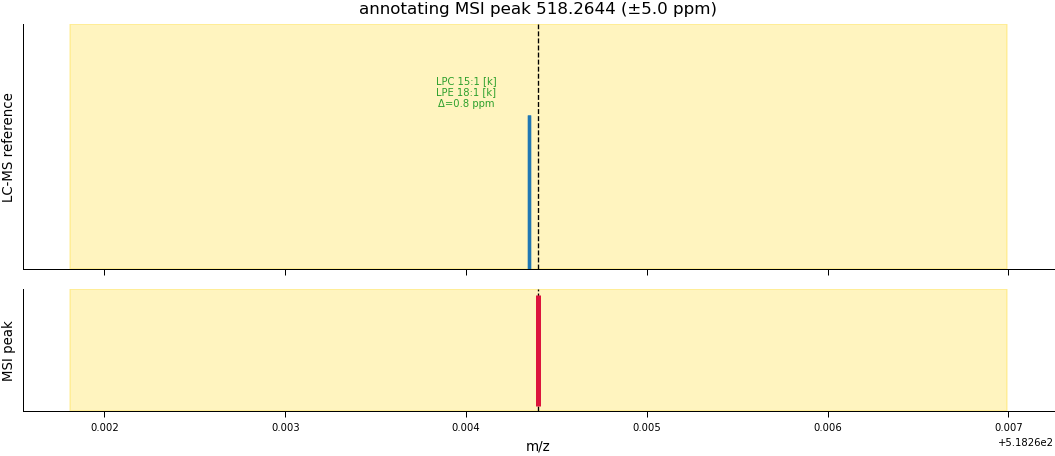

In [13]:
# the side-by-side ppm plot: LC-MS reference (top) vs the MSI peak (bottom)
axL, axM = cann.plot_ppm_match(observed, lcms, ppm_tol=5.0, span_ppm=40)
plt.tight_layout(); plt.show()


That single figure carries the whole lesson of sections 2 to 5. Adducts spread the
reference lipids across the axis. The ±5 ppm band is tiny but real. And two lipids, LPC 15:1
and LPE 18:1, both land their potassium adduct exactly on our peak. They are **isobaric**:
different molecules with the same mass, indistinguishable by mass alone. The ppm window
cannot break this tie, because the tie is at 0 ppm. We need outside information.

❓ **QUESTION.** Look at the gray sticks outside the gold band. They are real lipids in the
reference, but they sit too far from our peak. In your own words, why do we reject them even
though they are "close"?


## 7 · breaking the isobaric tie with bulk abundance

Why do LPC 15:1 and LPE 18:1 share a mass? Because their formulas happen to sum to the same
exact mass: swapping a choline head for an ethanolamine head and trading three carbons for
the right number of hydrogens lands you on the identical total. Mass cannot tell them apart.
But **biology** can. In brain tissue these two are not equally plausible.

The tie-breaker is a **quantitative bulk LC-MS** measurement: a separate run that reports
*how much* of each lipid is in brain, in nmol percent of total lipid. If one candidate is
abundant in brain and the other is essentially absent, the abundant one almost certainly
made our peak. We load `QuantitativeLCMS.csv` and look up our two candidates.


In [14]:
# bulk quantitative LC-MS: how much of each lipid is in brain (nmol % of total lipid)
qlcms = pd.read_csv(f"{REFS}/QuantitativeLCMS.csv").dropna(subset=["LIPID_ID"]).copy()
female_cols = ["Female", "Female.1", "Female.2", "Female.3"]
for c in female_cols:
    qlcms[c] = pd.to_numeric(qlcms[c], errors="coerce")
qlcms["abundance"] = qlcms[female_cols].mean(axis=1)   # mean over the 4 female samples

# look up our two tied candidates
for cand in ["LPE 18:1", "LPC 15:1"]:
    row = qlcms.loc[qlcms["LIPID_ID"] == cand, "abundance"]
    if len(row):
        print(f"  {cand:10s}: {row.iloc[0]:.5f} nmol% of total lipid  (MEASURED in bulk brain)")
    else:
        print(f"  {cand:10s}: not detected in the bulk LC-MS reference at all")


  LPE 18:1  : 0.01989 nmol% of total lipid  (MEASURED in bulk brain)
  LPC 15:1  : not detected in the bulk LC-MS reference at all


⚠️ **CHECKPOINT.** LPE 18:1 is measured in bulk brain at 0.0199 nmol percent. LPC 15:1
is **not detected at all**, not as a typo but because **odd-chain lyso-phosphatidylcholines
are vanishingly rare in mammalian brain**: animal fatty acids are overwhelmingly even-chain.
Let us confirm there is no odd-chain LPC anywhere in the quantitative reference.


In [15]:
# are there ANY odd-chain LPC species in the bulk reference?
lpc = qlcms[qlcms["LIPID_ID"].astype(str).str.startswith("LPC")]
odd = [s for s in lpc["LIPID_ID"] if any(f" {n}:" in str(s) for n in (13, 15, 17, 19, 21, 23))]
print("LPC species measured in bulk brain:", sorted(lpc["LIPID_ID"].tolist()))
print("\nodd-chain LPC species found:", odd if odd else "NONE")
print("\nverdict: the peak is LPE 18:1, the candidate that actually exists in brain.")


LPC species measured in bulk brain: ['LPC 16:0', 'LPC 16:1', 'LPC 18:0', 'LPC 18:1', 'LPC 18:2', 'LPC 20:0', 'LPC 20:1', 'LPC 20:3', 'LPC 20:4', 'LPC 22:0', 'LPC 22:6', 'LPC 24:0', 'LPC 24:1', 'LPC(O-16:0)', 'LPC(O-16:1) &/or LPC(P-16:0)', 'LPC(O-17:1) &/or LPC(P-17:0)', 'LPC(O-20:0)', 'LPC(O-24:0)']

odd-chain LPC species found: NONE

verdict: the peak is LPE 18:1, the candidate that actually exists in brain.


So abundance breaks the tie cleanly: the bulk LC-MS sees LPE 18:1 and never sees any
odd-chain LPC, so our peak at 518.2644 is **LPE 18:1**. This is exactly the call the project's
annotation table made. We can read it straight off the cleaned annotation row.


In [16]:
# confirm the project's master table assigned this peak to LPE 18:1
row = clean.loc[(clean["mz"] - observed).abs() < 0.01,
                ["mz", "Annotation", "AnnotationLCMSPrioritized", "Score", "Status"]]
print(row.to_string(index=False))


        mz Annotation AnnotationLCMSPrioritized  Score   Status
518.264437   LPE 18:1                  LPE 18:1   17.5 restored


The paper formalizes this rule: for the candidates of one peak, normalize their bulk
LC-MS molar fractions and, if the top one exceeds 80 percent of the summed abundance, keep
only that one. Here LPE 18:1 takes 100 percent of the measurable abundance (its rival
contributes zero), so it wins outright. The helper
`cl.annotation` does not need a separate function for this: the rule is the short loop you
just ran. The full EUCLID pipeline wraps it as
`Preprocessing.abundance_prioritization_lcms(matched_table, lcms_csv, threshold=0.8)`, but it
is the same 80-percent rule on the same numbers.

❓ **QUESTION.** Suppose both candidates had been abundant in brain, say a 55/45 split. The
80-percent rule would refuse to choose. What would you report then, and why is honesty about
the ambiguity better than picking one arbitrarily?


## 8 · the database layer: LIPID MAPS and HMDB

The LC-MS reference is a curated, brain-specific list. But many peaks have no LC-MS hit, and
for those we fall back to **chemical databases** that store the neutral exact mass of every
known lipid structure. Two matter here:

- **LIPID MAPS** (`structures.sdf`): the reference structure database for lipids. Each entry
  carries a structure, a formula, the **neutral exact mass**, and a shorthand abbreviation
  like `PC 34:1`. We match a peak by de-ionizing it (section 3) and looking for the closest
  neutral mass within 5 ppm.
- **HMDB**, the Human Metabolome Database, which METASPACE (the public annotation engine you
  will meet in a later notebook) reports against. HMDB and LIPID MAPS use different IDs, so a
  bridge table maps one to the other.

The mechanics are identical to what you already did: de-ionize under each adduct, then ppm-match
against the database's `EXACT_MASS`. We open LIPID MAPS, read a handful of entries so you see
the fields, and run the same de-ionize-and-match logic against it for our peak.


In [17]:
# peek at LIPID MAPS: structures with neutral exact masses and shorthand abbreviations
from rdkit import Chem
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")   # silence parser chatter

supp = Chem.SDMolSupplier(f"{DATA}/refs/structures.sdf")
records = []
for i, mol in enumerate(supp):
    if i >= 35000:       # scan the lipid-relevant block; the full file holds ~48k structures
        break
    if mol is None:
        continue
    p = mol.GetPropsAsDict()
    if "EXACT_MASS" in p and "ABBREVIATION" in p:
        records.append((p["ABBREVIATION"], float(p["EXACT_MASS"]), p.get("FORMULA", "")))
lipidmaps = pd.DataFrame(records, columns=["ABBREVIATION", "EXACT_MASS", "FORMULA"])
print(f"parsed {len(lipidmaps)} LIPID MAPS structures")
print(lipidmaps.head(5).to_string(index=False))


parsed 31879 LIPID MAPS structures
ABBREVIATION  EXACT_MASS  FORMULA
  FA 40:7;O3  626.491025 C40H66O5
     FA 16:0  256.240230 C16H32O2
      FA 2:0   60.021130   C2H4O2
      FA 3:0   74.036780   C3H6O2
      FA 4:0   88.052430   C4H8O2


In [18]:
# de-ionize our peak under each adduct, find the closest LIPID MAPS neutral mass within 5 ppm
masses = lipidmaps["EXACT_MASS"].to_numpy()
names = lipidmaps["ABBREVIATION"].to_numpy()
best_name, best_ppm, best_adduct = None, np.inf, None
for adduct, shift in cann.ADDUCTS.items():
    neutral = observed - shift                 # de-ionize
    j = int(np.argmin(np.abs(masses - neutral)))
    e = cann.ppm_error(neutral, masses[j])     # the same ppm formula
    if e <= 5.0 and e < best_ppm:
        best_name, best_ppm, best_adduct = names[j], e, adduct
print(f"closest LIPID MAPS hit for m/z {observed}:")
print(f"  {best_name}  as [M+{best_adduct[:-1]}]+   ({best_ppm:.2f} ppm)" if best_name
      else "  no hit within 5 ppm")


closest LIPID MAPS hit for m/z 518.2644:
  LPC 15:1  as [M+K]+   (1.04 ppm)


⚠️ **CHECKPOINT.** LIPID MAPS, with no LC-MS information at all, lands on **LPC 15:1 under
the potassium adduct at about 1 ppm**, one of the two isobars from our tie. That is the key
lesson about the database layer: LIPID MAPS stores *every* known lipid structure, including the
biologically rare odd-chain LPC 15:1, so the database can confirm a mass exists but it **cannot
break the isobaric tie either**, both LPC 15:1 and LPE 18:1 are in it as legitimate structures.
Only the *quantitative* bulk LC-MS from section 7, which knows what is actually abundant in brain,
settles the call. The databases give breadth (every known structure), while LC-MS gives confidence
(this lipid was really seen, and quantified, in brain). The paper combines all of these into a
single confidence score per peak, weighting LC-MS/MS most (8 points), bulk LC-MS less (2), and
database-only hits least (0). Peaks scoring above the threshold are the unambiguous ones, and a
further round of selection for the cleanest, most reproducible of those is what leaves the 173
named, trustworthy lipids in our substrate.

💡 **HINT.** The full annotator is one call, `Preprocessing.annotate_molecules(...)`, which
runs precisely the de-ionize-and-ppm-match loop you wrote above against LIPID MAPS, then merges
the LC-MS reference layer on top. You have now built its core by hand, so the one-liner holds no
mystery.

## 9 · reading a lipid name: nomenclature → properties

We have names now. But a name like `PC 38:6` is itself a compressed sentence, and to group
and color lipids we need to unpack it into properties. The shorthand encodes three things:

> **`PC 38:6`** = class **PC** (phosphatidylcholine), **38** total acyl carbons across the
> tails, **6** carbon-carbon double bonds (the degree of unsaturation).

Because MALDI cannot tell isomers apart, these are **sum compositions**: 38 total carbons,
not "an 18 and a 20". Two more wrinkles appear in real names:

- **sphingolipids** add a hydroxylation tag, `HexCer 42:2;O2`, and sometimes spell the
  sphingoid base and the N-acyl chain separately, `SM 18:1;O2/24:1`.
- **ether lipids** mark an ether-linked chain with `O-` or `P-`, as in `LPC O-18:2`.

We extract class, carbons, and double bonds with a few regular expressions, the same approach
the paper used to build its lipid property table. Let us unroll the parser on the messy real
names first.


In [19]:
# a transparent regex parser: class, total carbons, double bonds, ether flag
def parse_lipid(name):
    lipid_class = re.split(r"[ (]", name)[0]          # text before first space/paren -> class
    ether = bool(re.search(r"\bO-|\bP-", name))       # O-/P- prefix -> ether lipid
    m = re.search(r"(\d+):(\d+)", name)               # first 'C:DB' -> sum composition
    carbons = int(m.group(1)) if m else None
    double_bonds = int(m.group(2)) if m else None
    return lipid_class, carbons, double_bonds, ether

# try it on the tricky real names
for n in ["PC 38:6", "HexCer 42:2;O2", "SM 18:1;O2/24:1", "LPC O-18:2", "LPE 18:1"]:
    print(f"  {n:18s} -> class={parse_lipid(n)[0]:7s} carbons={parse_lipid(n)[1]}"
          f"  double_bonds={parse_lipid(n)[2]}  ether={parse_lipid(n)[3]}")

# make the per-chain caveat concrete: SM 18:1;O2/24:1 has TWO chains, the parser sees one.
# the correct sum composition adds both 'C:DB' pairs across the slash.
sm = "SM 18:1;O2/24:1"
pairs = re.findall(r"(\d+):(\d+)", sm)                          # [('18','1'), ('24','1')]
true_c = sum(int(c) for c, _ in pairs)                          # 18 + 24 = 42 carbons
true_db = sum(int(d) for _, d in pairs)                         # 1 + 1  = 2 double bonds
print(f"\n  caveat on {sm!r}:")
print(f"    naive regex grabs only the first chain -> {parse_lipid(sm)[1]}:{parse_lipid(sm)[2]} (the sphingoid base)")
print(f"    correct total across both chains        -> {true_c}:{true_db}  (this is the real sum composition)")

  PC 38:6            -> class=PC      carbons=38  double_bonds=6  ether=False
  HexCer 42:2;O2     -> class=HexCer  carbons=42  double_bonds=2  ether=False
  SM 18:1;O2/24:1    -> class=SM      carbons=18  double_bonds=1  ether=False
  LPC O-18:2         -> class=LPC     carbons=18  double_bonds=2  ether=True
  LPE 18:1           -> class=LPE     carbons=18  double_bonds=1  ether=False

  caveat on 'SM 18:1;O2/24:1':
    naive regex grabs only the first chain -> 18:1 (the sphingoid base)
    correct total across both chains        -> 42:2  (this is the real sum composition)


⚠️ **CHECKPOINT.** The parser reads `PC 38:6` as PC / 38 / 6, flags `LPC O-18:2` as an
ether lipid, and on `SM 18:1;O2/24:1` it grabs the first `C:DB` it finds, the sphingoid base
18:1, rather than the full chain. That last case is a real caveat, and the cell makes it
concrete: the naive regex reports 18:1, but the molecule has two chains, an 18:1 sphingoid
base and a 24:1 N-acyl tail, so the correct sum composition is **42:2** (18 + 24 carbons,
1 + 1 double bonds). Per-chain sphingolipid names need a smarter parser. The paper handles
all of these robustly with goslin, a dedicated lipid nomenclature tool, and the project ships
a tested `compress_lipid_name_robust` for exactly this. For grouping and coloring our 173
sum-composition names, where each name already carries a single total, the simple regex is enough.

Now run the parser across **all** 173 lipids and build a property table.

In [20]:
# parse every lipid in the substrate into a property table
props = pd.DataFrame([parse_lipid(n) for n in adata.var_names],
                     columns=["class", "carbons", "double_bonds", "ether"],
                     index=adata.var_names)
print("property table:", props.shape)
print(props.head(8).to_string())

# how many lipids per class?
print("\nlipids per class in the substrate:")
print(props["class"].value_counts().to_string())


property table: (173, 4)
                 class  carbons  double_bonds  ether
HexCer 42:2;O2  HexCer       42             2  False
HexCer 42:1;O2  HexCer       42             1  False
HexCer 40:1;O2  HexCer       40             1  False
PC 38:6             PC       38             6  False
PA 34:1             PA       34             1  False
SM 36:1;O2          SM       36             1  False
HexCer 40:2;O2  HexCer       40             2  False
PG 40:6             PG       40             6  False

lipids per class in the substrate:
class
PC         34
PE         21
PG         21
PS         18
PI         14
HexCer     12
PA         12
LPC        10
SM         10
Cer         7
LPE         6
TG          2
Hex2Cer     2
LPA         1
LPS         1
LPG         1
DG          1


These properties are exactly what every later notebook colors and groups by. A quick
look: do the classes spread across mass and unsaturation the way lipid chemistry predicts?
We plot every lipid by carbons against double bonds, sized by mass, colored by class.


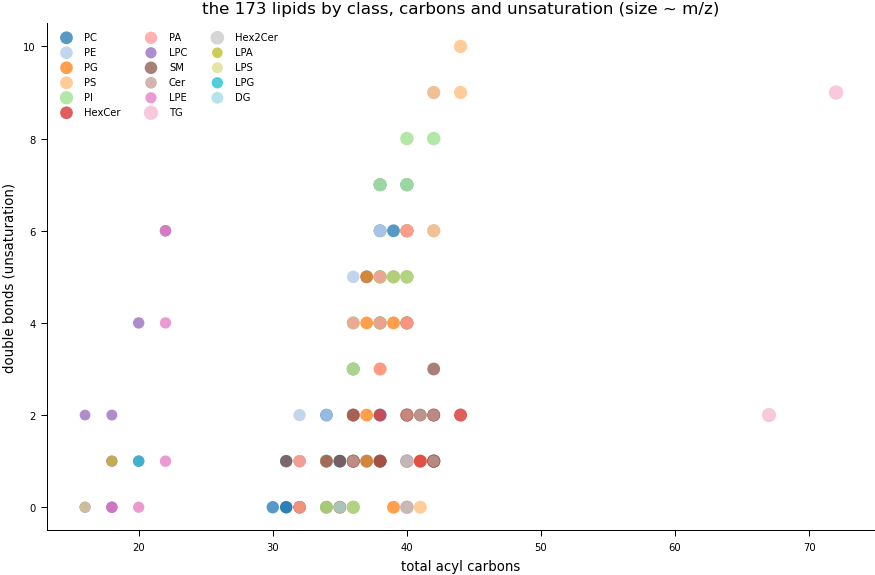

In [21]:
# the property landscape: carbons vs double bonds, colored by class
props = props.assign(mz=mz_of_lipid.values)
fig, ax = plt.subplots(figsize=(7.5, 5))
classes = props["class"].value_counts().index
cmap = plt.cm.tab20(np.linspace(0, 1, len(classes)))
for col, cls in zip(cmap, classes):
    sub = props[props["class"] == cls]
    ax.scatter(sub["carbons"], sub["double_bonds"], s=18 + sub["mz"] / 20,
               color=col, alpha=0.75, label=cls, edgecolor="none")
ax.set_xlabel("total acyl carbons"); ax.set_ylabel("double bonds (unsaturation)")
ax.set_title("the 173 lipids by class, carbons and unsaturation (size ~ m/z)")
ax.legend(ncol=3, fontsize=FS["xs"], loc="upper left")
plt.tight_layout(); plt.show()


❓ **QUESTION.** The lyso-lipids (LPC, LPE, LPA, with one tail removed) cluster at low
carbon counts, while the diacyl phospholipids spread to 40+ carbons. Why does losing a fatty
tail move a lipid to the left on this plot?


## 10 · m/z columns become lipid-named columns

Everything ties together here. The raw data started as a pixel-by-**m/z** matrix: columns
were masses. Annotation gives each surviving peak a name and a confidence score. The final
step keeps only the well-scored peaks and **renames the columns from masses to lipid names**.
That is precisely the transformation that produced the substrate you have been loading: its
columns are `PC 38:6`, `LPE 18:1`, `HexCer 42:2;O2`, not numbers.

Let us prove the chain end to end. We take our peak's mass, look up the name annotation gave
it, confirm that name is a column of the substrate, and show that same column carries real,
spatially structured intensity, an actual lipid map.


In [22]:
# the full chain for our peak: mass -> name -> a real column in the substrate
peak_mass = observed
peak_name = clean.loc[(clean["mz"] - peak_mass).abs() < 0.01, "Annotation"].iloc[0]
print(f"m/z {peak_mass}  ->  annotated as  '{peak_name}'")
print(f"is '{peak_name}' a column of the substrate? ", peak_name in list(adata.var_names))

# pull that column's values and confirm it is real signal, not noise
col = np.asarray(adata[:, peak_name].X).ravel()
print(f"\n'{peak_name}' intensity: mean {col.mean():.4f}, "
      f"max {col.max():.4f}, nonzero in {(col > 0).mean()*100:.0f}% of pixels")


m/z 518.2644  ->  annotated as  'LPE 18:1'
is 'LPE 18:1' a column of the substrate?  True



'LPE 18:1' intensity: mean 0.0014, max 0.0053, nonzero in 100% of pixels


🔬 **TASK.** Draw the spatial map of our newly named lipid across both sections. The
helper `cplot.spatial_lipid` places every pixel at its CCF coordinate and colors it by
intensity, with a faint anatomical map underneath. A real lipid traces anatomy; pure noise
would not.


/tmp/ipykernel_1170057/1165595800.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


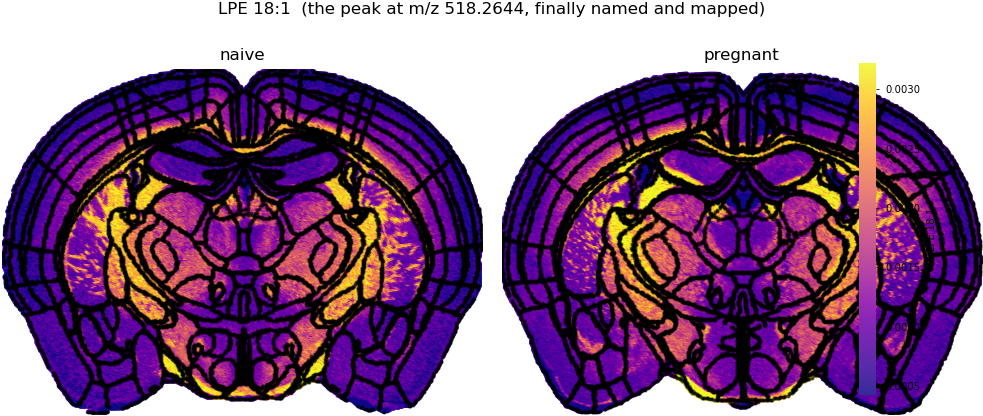

In [23]:
# the named lipid, mapped onto the tissue in both sections
cplot.spatial_lipid(adata, peak_name, section_key="SectionID", title_key="Condition")
plt.suptitle(f"{peak_name}  (the peak at m/z {peak_mass}, finally named and mapped)",
             fontsize=FS["m"], y=1.02)
plt.tight_layout(); plt.show()


⚠️ **CHECKPOINT.** The map is not random speckle: LPE 18:1 paints coherent anatomical
structure across the section, the same pattern in control and pregnant. That spatial coherence
is the final proof the annotation is real. A bare number became a named molecule, and the named
molecule draws a picture of the brain.

This is the bridge to the rest of the course. Every analysis from here on, the embeddings, the
lipizones, the control-versus-pregnant differential test, runs on **named, scored lipid
columns**. We built those names by hand in this notebook: a peak is a mass, an adduct spreads
one lipid across several masses, de-ionization recovers the neutral mass, the ppm window decides
what matches, an LC-MS reference donates the name, bulk abundance breaks the isobaric ties, and
databases fill the gaps. The 173 lipids in `sections_pair.h5ad` are the high-confidence
peaks that survived this whole process: they score above the threshold and then pass the
project's further selection of the cleanest, most reproducible signals to carry into analysis.

## what you can now do

- explain why an MSI peak is a **mass, not a lipid**, until it is annotated.
- list the four positive-mode **adducts** and compute the masses one lipid shows up at.
- **de-ionize** an observed peak (neutral = observed − adduct) to compare against a database.
- write the **ppm formula** and state that 5 ppm at m/z 800 is a 0.004 Da window.
- match a peak against an **LC-MS reference** with `cl.annotation.match_lcms` and read the
  side-by-side ppm plot from `cl.annotation.plot_ppm_match`.
- recognise an **isobaric tie** and break it with bulk LC-MS abundance (the 80-percent rule).
- parse a lipid name into **class, carbons, double bonds, ether** with a regex.
- explain how **m/z columns become lipid-named columns**, the step that produced our substrate.

🔬 **TASK (optional, for the curious).** Pick another peak from the LC-MS reference, say a
PC near m/z 800, run `cl.annotation.match_lcms` and `cl.annotation.plot_ppm_match` on it, and
see whether it is a clean single hit or another isobaric tie. The crowded the mass region, the
more ties you will find.


matches within 5 ppm of m/z 798.541:
    Lipid Adduct        m/z      ppm
  PC 34.1      k 798.540961 0.048839
PE O-40:7     na 798.541610 0.763893


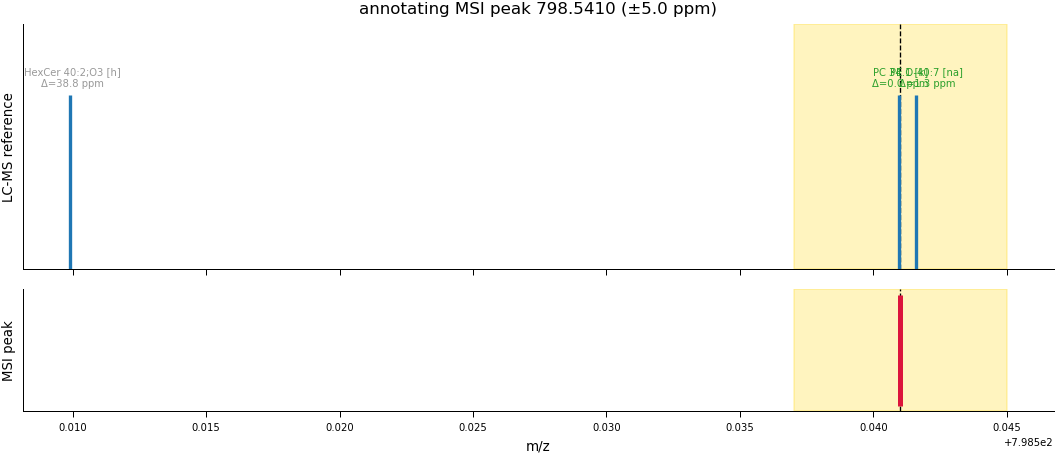

In [24]:
# OPTIONAL: try the workflow on a peak you choose. Edit `my_peak` and run.
my_peak = 798.5410   # a PC-region mass; change me

my_hits = cann.match_lcms(my_peak, lcms, ppm_tol=5.0)
print(f"matches within 5 ppm of m/z {my_peak}:")
print(my_hits.to_string(index=False) if len(my_hits) else "  none")
cann.plot_ppm_match(my_peak, lcms, ppm_tol=5.0, span_ppm=40)
plt.tight_layout(); plt.show()


## References

- Fusar Bassini et al. *The lipidomic architecture of the mouse brain.* bioRxiv 2025.10.13.682018. The EUCLID method and the Lipid Brain Atlas: https://www.biorxiv.org/content/10.1101/2025.10.13.682018v1
- uMAIA: probabilistic normalization of mass-spectrometry imaging. *Nature Methods* (2025), s41592-025-02771-7.
- Allen Mouse Brain Common Coordinate Framework v3 (CCFv3), Allen Institute for Brain Science.
- Explore the atlas interactively: https://lbae-v2.epfl.ch/
